In [61]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error , classification_report

In [24]:
data = pd.read_csv('Diabetes_Classification.csv')

In [25]:
data.shape

(128, 11)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    object 
 2   BMI                         128 non-null    int64  
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  128 non-null    object 
 7   Smoking                     128 non-null    object 
 8   Diet                        128 non-null    object 
 9   Exercise                    128 non-null    object 
 10  Diagnosis                   128 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.1+ KB


In [27]:
data

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20,Normal,80,5.0,No,No,Healthy,Regular,No
...,...,...,...,...,...,...,...,...,...,...,...
123,17,Female,15,Normal,100,5.7,No,Yes,Poor,No,Yes
124,22,Male,19,Normal,120,6.4,No,Yes,Poor,No,Yes
125,27,Female,24,High,140,7.1,No,Yes,Poor,No,Yes
126,32,Male,29,High,160,7.8,No,Yes,Poor,No,Yes


In [28]:
def pre_process_data(df): 
    data["Gender"] = df["Gender"].map({'Female' : 0, 'Male' : 1})
    data["Blood Pressure"] = df["Blood Pressure"].map({'Normal' : 1, 'Low' : 1 , 'High' : 2})
    data["Family History of Diabetes"] = df["Family History of Diabetes"].map({'No' : 0, 'Yes' : 1})
    data["Smoking"] = df["Smoking"].map({'No' : 0, 'Yes' : 1})
    data["Diet"] = df["Diet"].map({'Healthy' : 0, 'Poor' : 1})
    data["Exercise"] = df["Exercise"].map({'Regular' : 0, 'No' : 1})
    data["Diagnosis"] = df["Diagnosis"].map({'No' : 0, 'Yes' : 1})

    return df

data = pre_process_data(data) 
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    int64  
 2   BMI                         128 non-null    int64  
 3   Blood Pressure              128 non-null    int64  
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  128 non-null    int64  
 7   Smoking                     128 non-null    int64  
 8   Diet                        128 non-null    int64  
 9   Exercise                    128 non-null    int64  
 10  Diagnosis                   128 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 11.1 KB


In [53]:
X = data.drop(columns=["Diagnosis"])
y = data.Diagnosis

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_prediction = model.predict(X_test)

print("Logistic Regression: ")
print(classification_report(y_test, y_prediction)) 

Logistic Regression: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         3

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



In [57]:
diagnosis_map = {0:'No', 1:'Yes'}
decoded_prediction = [diagnosis_map[pred] for pred in y_prediction]

decoded_prediction = pd.Series(y_prediction).map(diagnosis_map)

actual = pd.Series(y_test).map(diagnosis_map)
Comparision_df = pd.DataFrame({
    'Actual ':actual,
    'Prediction' : decoded_prediction
})
print(Comparision_df.head(10))

  Actual  Prediction
0      No         No
1     NaN         No
2     NaN        Yes
3     NaN         No
4     NaN         No
5     NaN         No
6     NaN         No
7     NaN         No
8     NaN        Yes
9     NaN         No


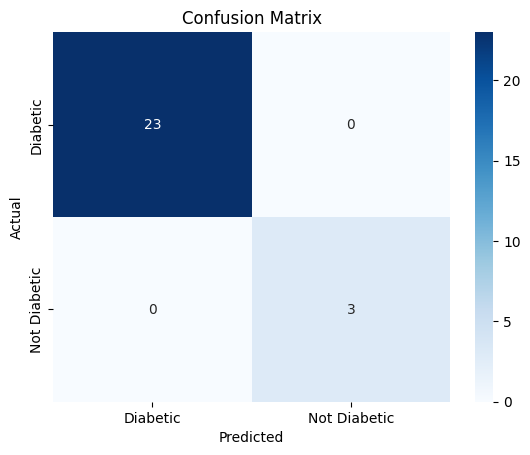

In [66]:
cm = confusion_matrix(actual, decoded_prediction)
labels='Diabetic','Not Diabetic'
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()